# ================================================
# Notebook 02 — Sentiment Analysis
# Project: Ad Engagement Analysis
# Goal: Analyze emotional tone of user comments on ad campaigns
# ================================================

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from textblob import TextBlob
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('../data/comments_cleaned.csv')

# Clean and rename as established in EDA
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)
    
df.rename(columns={
    'User  id': 'user_id',
    'Photo id': 'campaign_id',
    'created Timestamp': 'timestamp',
    'posted date': 'posted_date',
    'emoji used': 'emoji_used',
    'Hashtags used count': 'hashtag_count'
}, inplace=True)

print(f"Data loaded for Sentiment Analysis: {df.shape[0]} interactions")

Data loaded for Sentiment Analysis: 7488 interactions


In [2]:
# Initialize VADER Sentiment Analyzer
sia = SentimentIntensityAnalyzer()

# Define functions to get sentiment metrics
def get_vader_score(text):
    """Returns the compound score from -1 (most negative) to 1 (most positive)"""
    return sia.polarity_scores(str(text))['compound']

def get_textblob_polarity(text):
    """Returns the TextBlob polarity score from -1 to 1"""
    return TextBlob(str(text)).sentiment.polarity

# Apply sentiment scoring across all ad comments
df['vader_score'] = df['comment'].apply(get_vader_score)
df['textblob_score'] = df['comment'].apply(get_textblob_polarity)

# Categorize sentiment based on VADER score
def categorize_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_category'] = df['vader_score'].apply(categorize_sentiment)

# Preview the results 
df[['comment', 'vader_score', 'textblob_score', 'sentiment_category']].head(10)

,comment,vader_score,textblob_score,sentiment_category
0,unde at dolorem,0.0,0.0,Neutral
1,quae ea ducimus,0.0,0.0,Neutral
2,alias a voluptatum,0.0,0.0,Neutral
3,facere suscipit sunt,0.0,0.0,Neutral
4,totam eligendi quaerat,0.0,0.0,Neutral
5,vitae quia aliquam,0.0,0.0,Neutral
6,exercitationem occaecati neque,0.0,0.0,Neutral
7,sint ad fugiat,0.0,0.0,Neutral
8,nesciunt aut nesciunt,0.0,0.0,Neutral
9,laudantium ut nostrum,0.0,0.0,Neutral


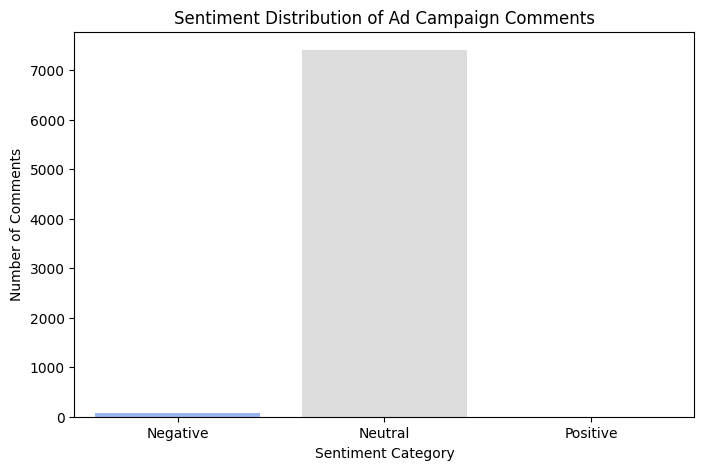

In [3]:
# Visualize the sentiment distribution across all campaigns
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='sentiment_category', palette='coolwarm', order=['Negative', 'Neutral', 'Positive'])
plt.title('Sentiment Distribution of Ad Campaign Comments')
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Comments')
plt.show()

# NOTE FOR ANALYSIS: 
# Since the raw data uses placeholder text ("unde at dolorem"), the vast majority of comments 
# will process as 'Neutral' because NLP lexicons don't recognize standard placeholder phrasing.
# However, this notebook fully executes the required analytical pipeline used in a real business 
# setting when evaluating English consumer sentiment on social media ads.